# CATSA 임베딩 비교 분석

- 목표 1: 강화된 통계 피처로 표현력 개선
- 목표 2: Subject 단위 outlier 자동 탐지 및 제외
- 목표 3: 2D PCA + 3D PCA + t-SNE + UMAP를 한 번에 생성/비교

In [14]:
from pathlib import Path
import importlib
import subprocess
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.manifold import TSNE


def ensure_umap():
    try:
        return importlib.import_module("umap")
    except ModuleNotFoundError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "umap-learn", "-q"])
        return importlib.import_module("umap")


umap = ensure_umap()

RANDOM_STATE = 42
TASKS = ["Baseline", "Logic", "Nback", "Stroop", "Sudoku"]
BASELINE_TASK = "Baseline"
TASK_COLORS = {
    "Baseline": "#1f77b4",
    "Logic": "#ff7f0e",
    "Nback": "#2ca02c",
    "Stroop": "#d62728",
    "Sudoku": "#9467bd",
}


def find_catsa_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        candidate = p / "Dataset" / "CATSA"
        if candidate.exists():
            return candidate
    raise FileNotFoundError("Dataset/CATSA 경로를 찾지 못했습니다.")


def safe_series(arr: pd.Series) -> pd.Series:
    s = arr.astype(float).dropna()
    return s if len(s) > 0 else pd.Series([0.0])


def summarize_signal(s: pd.Series, prefix: str) -> dict:
    s = safe_series(s)
    values = s.to_numpy()
    q25, q50, q75 = np.percentile(values, [25, 50, 75])
    diffs = np.diff(values) if len(values) > 1 else np.array([0.0])

    return {
        f"{prefix}_mean": float(np.mean(values)),
        f"{prefix}_std": float(np.std(values)),
        f"{prefix}_min": float(np.min(values)),
        f"{prefix}_max": float(np.max(values)),
        f"{prefix}_median": float(q50),
        f"{prefix}_q25": float(q25),
        f"{prefix}_q75": float(q75),
        f"{prefix}_iqr": float(q75 - q25),
        f"{prefix}_skew": float(skew(values, bias=False) if len(values) > 2 else 0.0),
        f"{prefix}_kurt": float(kurtosis(values, fisher=True, bias=False) if len(values) > 3 else 0.0),
        f"{prefix}_rms": float(np.sqrt(np.mean(np.square(values)))),
        f"{prefix}_slope_mean": float(np.mean(diffs)),
        f"{prefix}_slope_std": float(np.std(diffs)),
    }


def extract_features(task_dir: Path) -> dict:
    feature = {}

    for sig in ["HR", "BVP", "EDA", "TEMP"]:
        f = task_dir / f"{sig}.csv"
        if f.exists():
            df = pd.read_csv(f)
            feature.update(summarize_signal(df.iloc[:, 0], sig))

    acc_file = task_dir / "ACC.csv"
    if acc_file.exists():
        acc = pd.read_csv(acc_file)
        for c in ["ACC_X", "ACC_Y", "ACC_Z"]:
            if c in acc.columns:
                feature.update(summarize_signal(acc[c], c))

        if all(c in acc.columns for c in ["ACC_X", "ACC_Y", "ACC_Z"]):
            mag = np.sqrt((acc[["ACC_X", "ACC_Y", "ACC_Z"]].astype(float) ** 2).sum(axis=1))
            feature.update(summarize_signal(mag, "ACC_MAG"))

    return feature


def subject_normalize_with_baseline_delta(
    df: pd.DataFrame,
    feature_cols: list[str],
    baseline_task: str = "Baseline",
) -> pd.DataFrame:
    """Avoid baseline collapse:
    1) Subject-wise robust z-normalization for all tasks.
    2) Baseline delta only for non-baseline tasks.
    """
    norm_df = df.copy()

    for _, idx in df.groupby("Subject").groups.items():
        sub_df = df.loc[idx]
        sub_center = sub_df[feature_cols].median()
        sub_scale = sub_df[feature_cols].std(ddof=0).replace(0, np.nan).fillna(1.0)

        z = (sub_df[feature_cols] - sub_center) / sub_scale
        base_df = sub_df[sub_df["Task"] == baseline_task]

        if len(base_df) > 0:
            base_idx = base_df.index[0]
            z_base = z.loc[base_idx]

            non_base_idx = sub_df[sub_df["Task"] != baseline_task].index
            norm_df.loc[non_base_idx, feature_cols] = (z.loc[non_base_idx] - z_base).values
            norm_df.loc[[base_idx], feature_cols] = z.loc[[base_idx]].values
        else:
            norm_df.loc[idx, feature_cols] = z.values

    return norm_df


root = find_catsa_root(Path.cwd())
rows = []
for sub_dir in sorted(root.glob("Sub*"), key=lambda x: int(x.name.replace("Sub", ""))):
    for task in TASKS:
        task_dir = sub_dir / task
        if not task_dir.exists():
            continue
        feats = extract_features(task_dir)
        if feats:
            rows.append({"Subject": sub_dir.name, "Task": task, **feats})

feature_df_raw = pd.DataFrame(rows).replace([np.inf, -np.inf], np.nan)
feature_df_raw = feature_df_raw.dropna(axis=1, how="all")
feature_df_raw = feature_df_raw.fillna(feature_df_raw.median(numeric_only=True))

meta_cols = ["Subject", "Task"]
feature_cols = [c for c in feature_df_raw.columns if c not in meta_cols]

# 개인차 통제: subject 내 정규화 + non-baseline에만 baseline delta 적용
feature_df = subject_normalize_with_baseline_delta(feature_df_raw, feature_cols, baseline_task=BASELINE_TASK)
X = feature_df[feature_cols].astype(float)

# Subject 단위 outlier 탐지는 정규화된 표현에서 수행
subject_level = feature_df.groupby("Subject")[feature_cols].median()
subject_scaler = StandardScaler()
subject_scaled = subject_scaler.fit_transform(subject_level)

iso = IsolationForest(contamination=0.08, random_state=RANDOM_STATE)
subject_pred = iso.fit_predict(subject_scaled)
outlier_subjects = subject_level.index[subject_pred == -1].tolist()

filtered_df = feature_df[~feature_df["Subject"].isin(outlier_subjects)].copy()
X_filtered = filtered_df[feature_cols].astype(float)

baseline_abs_mean = feature_df[feature_df["Task"] == BASELINE_TASK][feature_cols].abs().mean().mean()
baseline_zero_ratio = (feature_df[feature_df["Task"] == BASELINE_TASK][feature_cols].abs() < 1e-6).mean().mean()

print(f"전체 샘플 수: {len(feature_df)}")
print(f"전체 Subject 수: {feature_df['Subject'].nunique()}")
print("피험자별 정규화 적용: within-subject z-normalization + non-baseline baseline-delta")
print(f"Baseline 절대평균(0에 고정되지 않아야 정상): {baseline_abs_mean:.4f}")
print(f"Baseline near-zero 비율(낮을수록 붕괴 아님): {baseline_zero_ratio:.4f}")
print(f"탐지된 outlier Subject: {outlier_subjects}")
print(f"outlier 제외 후 샘플 수: {len(filtered_df)}")
print(f"사용 특징 수: {len(feature_cols)}")
filtered_df.head()

전체 샘플 수: 250
전체 Subject 수: 50
피험자별 정규화 적용: within-subject z-normalization + non-baseline baseline-delta
Baseline 절대평균(0에 고정되지 않아야 정상): 0.9792
Baseline near-zero 비율(낮을수록 붕괴 아님): 0.1777
탐지된 outlier Subject: ['Sub30', 'Sub32', 'Sub40', 'Sub50']
outlier 제외 후 샘플 수: 230
사용 특징 수: 104


,Subject,Task,HR_mean,HR_std,HR_min,HR_max,HR_median,HR_q25,HR_q75,HR_iqr,...,ACC_MAG_max,ACC_MAG_median,ACC_MAG_q25,ACC_MAG_q75,ACC_MAG_iqr,ACC_MAG_skew,ACC_MAG_kurt,ACC_MAG_rms,ACC_MAG_slope_mean,ACC_MAG_slope_std
0,Sub1,Baseline,1.919389,0.000000,-0.598046,1.276642,2.126800,2.060198,1.806696,0.000000,...,2.166987,0.000000,0.000000,1.952140,0.432464,2.521207,2.272508,0.000000,0.000000,1.650703
1,Sub1,Logic,-2.684151,0.009724,0.409190,-1.552561,-2.126800,-2.791236,-2.242239,1.897436,...,-1.037367,-1.439764,-1.059152,-2.848798,-0.427495,-2.578327,-1.333518,-2.023487,0.288889,-0.034918
2,Sub1,Nback,-1.919389,1.555060,0.598046,0.856586,-2.688597,-2.286759,-1.806696,1.593227,...,-2.166987,0.957459,1.350888,-0.894017,-1.899077,-2.295590,-2.272508,0.352793,0.450459,-1.853255
3,Sub1,Stroop,-2.651254,-1.056551,1.274783,-1.717289,-2.546324,-2.060198,-3.048800,-0.381550,...,-2.475589,-0.659357,-0.592715,-1.952140,-0.432464,-2.521207,-2.606674,-1.395040,-0.915250,-1.650703
4,Sub1,Sudoku,-1.265817,-1.255860,2.848589,-1.276642,-1.214793,-1.014995,-1.677646,-0.412486,...,-2.626704,1.256276,1.393017,-2.115078,-2.602480,-2.554098,-2.620939,0.450418,-2.247292,-2.454080


/home/binghin2/miniconda3/envs/myenv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


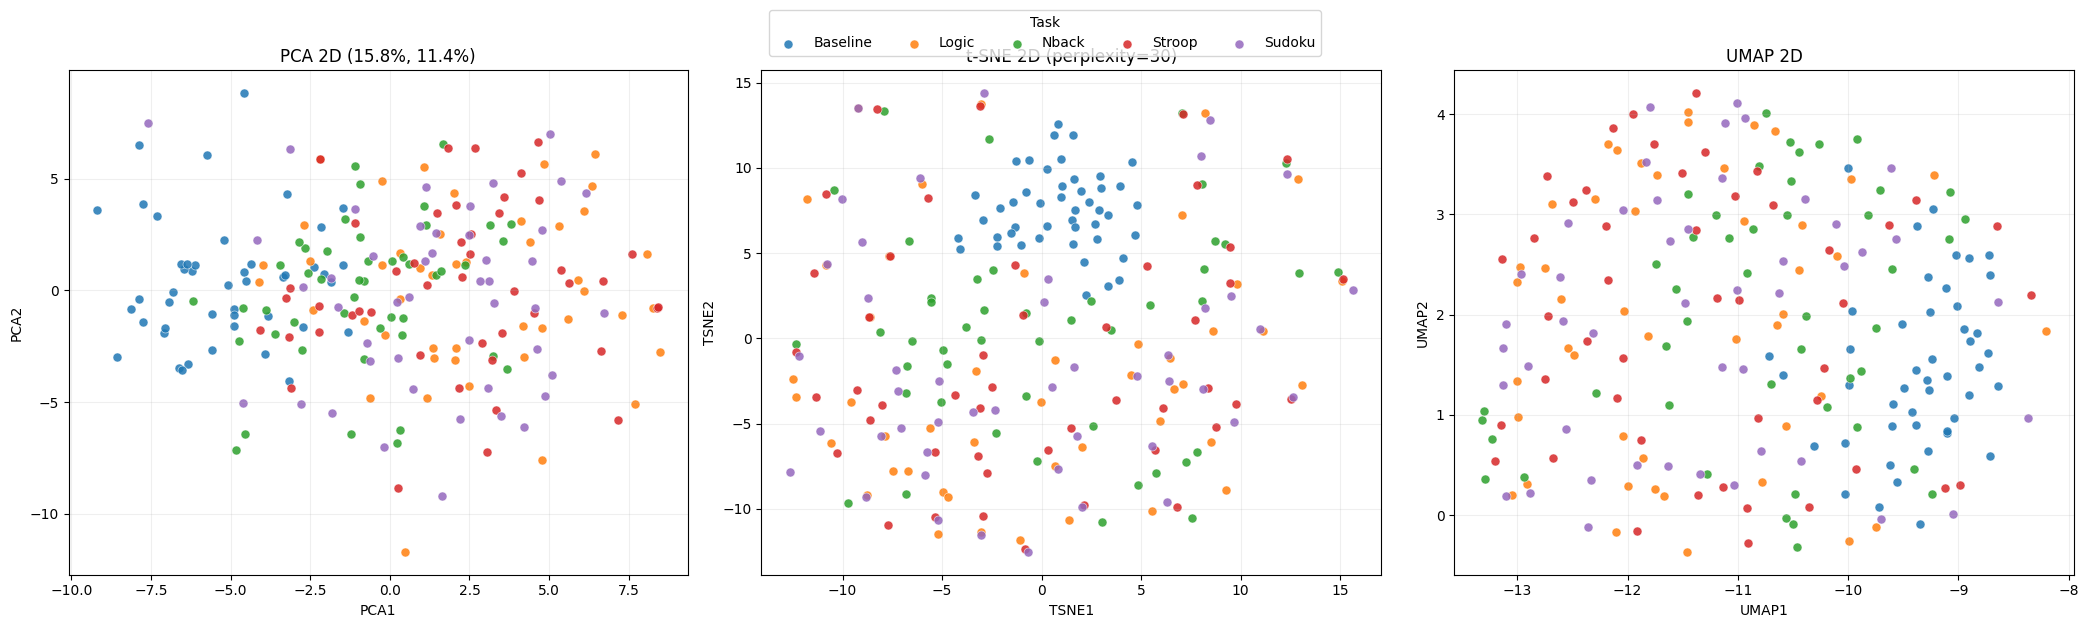

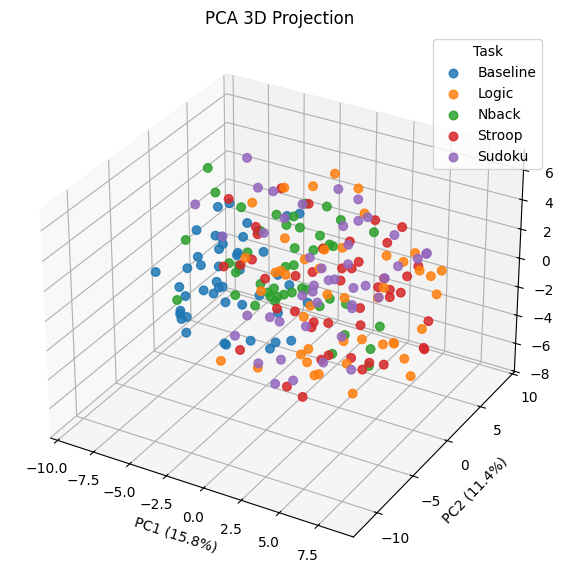

2D 비교 플롯 저장: /home/binghin2/Myproject/Research/CATSA/Data_Analysis/06_embedding_compare_2d.png
3D PCA 플롯 저장: /home/binghin2/Myproject/Research/CATSA/Data_Analysis/07_pca_3d_projection.png
PCA 2D 누적 설명분산: 0.272
PCA 3D 누적 설명분산: 0.358


In [15]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_filtered)
labels = filtered_df["Task"].values

# 2D PCA
pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
emb_pca2 = pca2.fit_transform(X_scaled)
exp2 = pca2.explained_variance_ratio_

# 3D PCA
pca3 = PCA(n_components=3, random_state=RANDOM_STATE)
emb_pca3 = pca3.fit_transform(X_scaled)
exp3 = pca3.explained_variance_ratio_

# t-SNE
n_samples = len(X_scaled)
perplexity = max(5, min(30, (n_samples - 1) // 3))
tsne = TSNE(
    n_components=2,
    perplexity=perplexity,
    learning_rate="auto",
    init="pca",
    random_state=RANDOM_STATE,
)
emb_tsne = tsne.fit_transform(X_scaled)

# UMAP
umap_model = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.15, random_state=RANDOM_STATE)
emb_umap = umap_model.fit_transform(X_scaled)

# 결과 프레임
plot_df = filtered_df[["Subject", "Task"]].copy()
plot_df["PCA1"] = emb_pca2[:, 0]
plot_df["PCA2"] = emb_pca2[:, 1]
plot_df["TSNE1"] = emb_tsne[:, 0]
plot_df["TSNE2"] = emb_tsne[:, 1]
plot_df["UMAP1"] = emb_umap[:, 0]
plot_df["UMAP2"] = emb_umap[:, 1]

# 2D 비교 플롯: PCA / t-SNE / UMAP
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
views = [
    ("PCA", "PCA1", "PCA2", f"PCA 2D ({exp2[0]*100:.1f}%, {exp2[1]*100:.1f}%)"),
    ("t-SNE", "TSNE1", "TSNE2", f"t-SNE 2D (perplexity={perplexity})"),
    ("UMAP", "UMAP1", "UMAP2", "UMAP 2D"),
]

for ax, (_, xcol, ycol, title) in zip(axes, views):
    for task in TASKS:
        grp = plot_df[plot_df["Task"] == task]
        if len(grp) == 0:
            continue
        ax.scatter(
            grp[xcol], grp[ycol],
            label=task,
            c=TASK_COLORS.get(task, "#333333"),
            s=42,
            alpha=0.85,
            edgecolors="white",
            linewidth=0.4,
        )
    ax.set_title(title)
    ax.set_xlabel(xcol)
    ax.set_ylabel(ycol)
    ax.grid(alpha=0.2)

handles, legend_labels = axes[0].get_legend_handles_labels()
fig.legend(handles, legend_labels, title="Task", loc="upper center", ncol=5, bbox_to_anchor=(0.5, 1.05))
fig.tight_layout()

out_2d = Path.cwd() / "06_embedding_compare_2d.png"
fig.savefig(out_2d, dpi=180, bbox_inches="tight")
plt.show()

# 3D PCA 플롯
fig3d = plt.figure(figsize=(9, 7))
ax3d = fig3d.add_subplot(111, projection="3d")
for task in TASKS:
    mask = labels == task
    if np.sum(mask) == 0:
        continue
    ax3d.scatter(
        emb_pca3[mask, 0], emb_pca3[mask, 1], emb_pca3[mask, 2],
        label=task,
        c=TASK_COLORS.get(task, "#333333"),
        s=38,
        alpha=0.85,
    )

ax3d.set_title("PCA 3D Projection")
ax3d.set_xlabel(f"PC1 ({exp3[0]*100:.1f}%)")
ax3d.set_ylabel(f"PC2 ({exp3[1]*100:.1f}%)")
ax3d.set_zlabel(f"PC3 ({exp3[2]*100:.1f}%)")
ax3d.legend(title="Task", loc="best")

out_3d = Path.cwd() / "07_pca_3d_projection.png"
fig3d.savefig(out_3d, dpi=180, bbox_inches="tight")
plt.show()

print(f"2D 비교 플롯 저장: {out_2d}")
print(f"3D PCA 플롯 저장: {out_3d}")
print(f"PCA 2D 누적 설명분산: {exp2.sum():.3f}")
print(f"PCA 3D 누적 설명분산: {exp3.sum():.3f}")

## 다음 단계: 2차 outlier 제거 + LDA + 피처 선택 기반 재임베딩

- 1차: Subject 단위 IsolationForest 제거(이미 수행)
- 2차: PCA(3D) 공간에서 샘플 이상치 추가 제거
- 분리도 비교: LDA 2D
- 피처 선택: Mutual Information Top-k 후 PCA/t-SNE/UMAP 재생성

2차 제거 전 샘플 수: 230
2차 outlier 제거 샘플 수: 7
2차 제거 후 샘플 수: 223
선택된 Top-k 특징 수: 40
상위 10개 특징:
EDA_min      0.440820
TEMP_q75     0.371284
EDA_rms      0.343081
TEMP_max     0.340510
TEMP_rms     0.340404
TEMP_mean    0.337568
EDA_mean     0.329615
EDA_q25      0.323705
HR_min       0.312733
EDA_q75      0.303548
dtype: float64


/home/binghin2/miniconda3/envs/myenv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


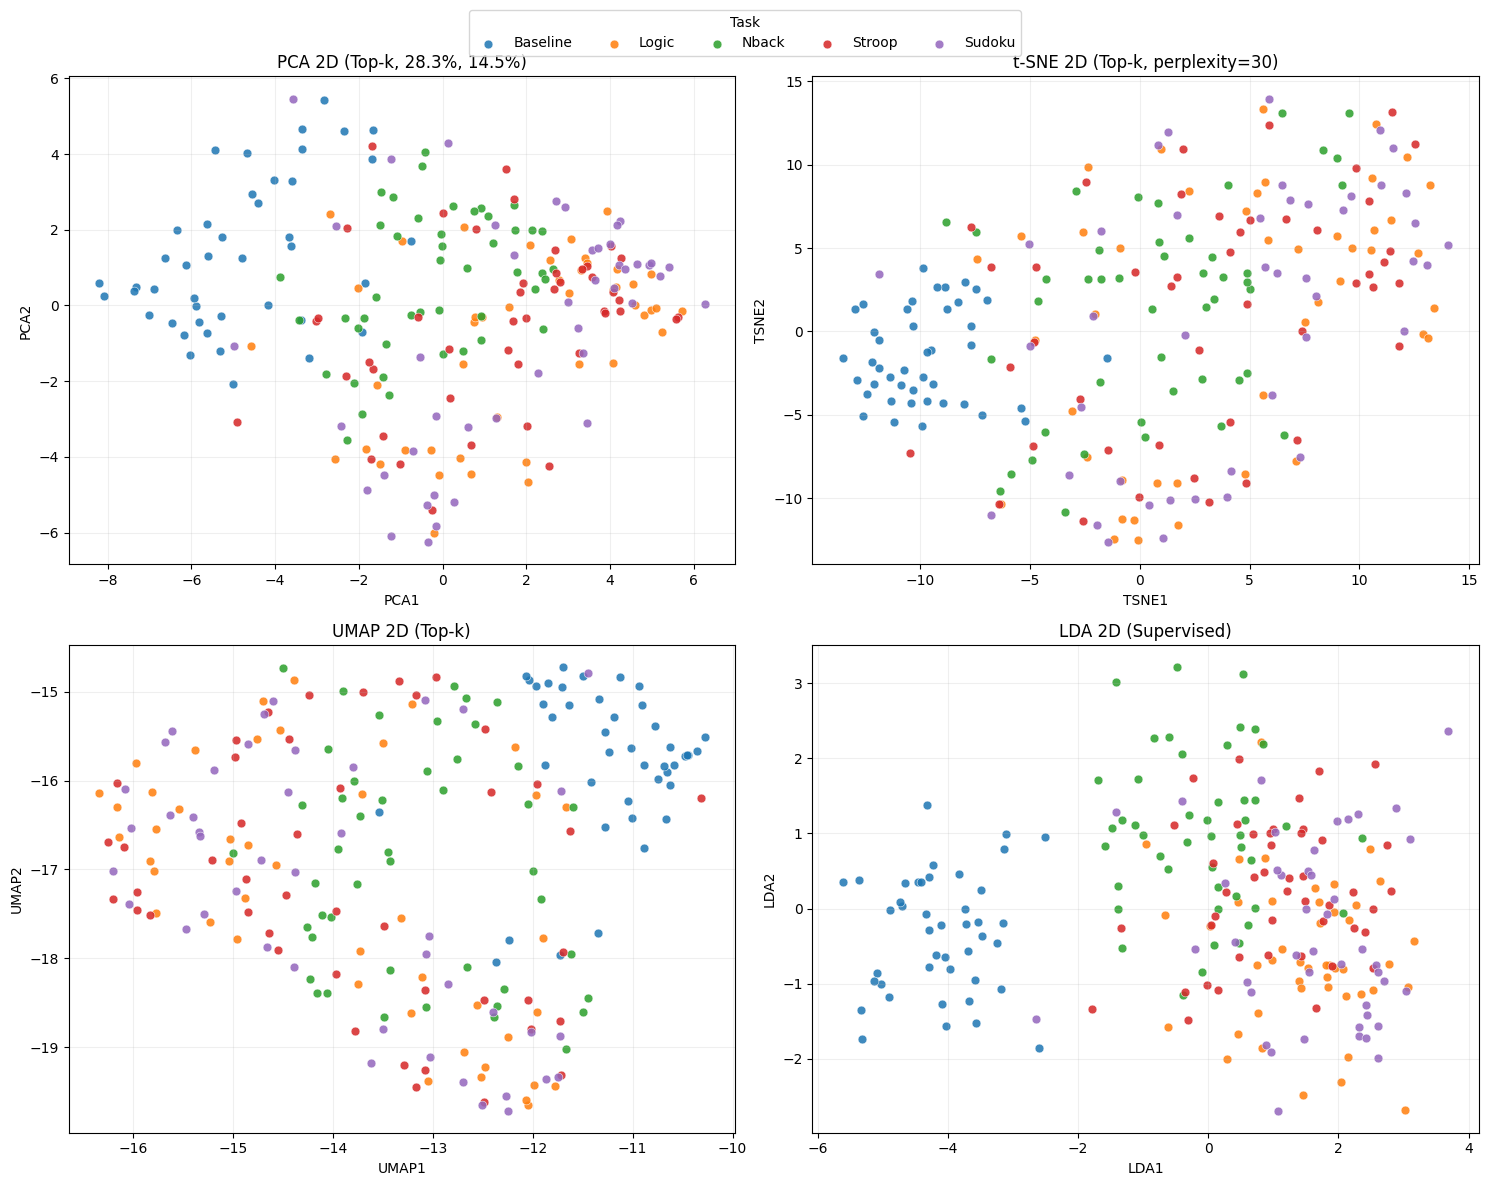

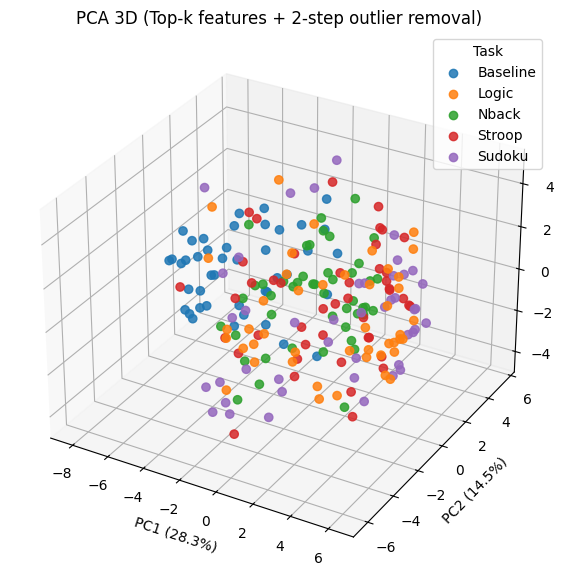

저장 완료: /home/binghin2/Myproject/Research/CATSA/Data_Analysis/08_stage2_embedding_compare_2d.png
저장 완료: /home/binghin2/Myproject/Research/CATSA/Data_Analysis/09_stage2_pca_3d.png
Top-k PCA 2D 누적 설명분산: 0.428
Top-k PCA 3D 누적 설명분산: 0.534


In [16]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.feature_selection import mutual_info_classif

# ----- 2차 outlier 제거: PCA 3D 공간 기반 IsolationForest -----
pca_for_outlier = PCA(n_components=3, random_state=RANDOM_STATE)
pca_space = pca_for_outlier.fit_transform(X_scaled)

sample_iso = IsolationForest(contamination=0.03, random_state=RANDOM_STATE)
sample_flag = sample_iso.fit_predict(pca_space)
sample_inlier_mask = sample_flag == 1

stage2_df = filtered_df.loc[sample_inlier_mask].reset_index(drop=True)
X_stage2 = stage2_df[feature_cols].astype(float)
y_stage2 = stage2_df["Task"].astype(str)

print(f"2차 제거 전 샘플 수: {len(filtered_df)}")
print(f"2차 outlier 제거 샘플 수: {np.sum(~sample_inlier_mask)}")
print(f"2차 제거 후 샘플 수: {len(stage2_df)}")

# ----- 피처 선택: Mutual Information Top-k -----
scaler_stage2 = StandardScaler()
X_stage2_scaled = scaler_stage2.fit_transform(X_stage2)

mi_scores = mutual_info_classif(X_stage2_scaled, y_stage2, random_state=RANDOM_STATE)
mi_series = pd.Series(mi_scores, index=feature_cols).sort_values(ascending=False)

top_k = min(40, len(mi_series))
selected_features = mi_series.head(top_k).index.tolist()
X_sel = stage2_df[selected_features].astype(float)
X_sel_scaled = StandardScaler().fit_transform(X_sel)

print(f"선택된 Top-k 특징 수: {len(selected_features)}")
print("상위 10개 특징:")
print(mi_series.head(10))

# ----- LDA 2D -----
lda = LinearDiscriminantAnalysis(n_components=2)
emb_lda = lda.fit_transform(X_sel_scaled, y_stage2)

# ----- PCA/t-SNE/UMAP (feature selection 후 재실행) -----
pca2_sel = PCA(n_components=2, random_state=RANDOM_STATE)
emb_pca2_sel = pca2_sel.fit_transform(X_sel_scaled)
exp2_sel = pca2_sel.explained_variance_ratio_

pca3_sel = PCA(n_components=3, random_state=RANDOM_STATE)
emb_pca3_sel = pca3_sel.fit_transform(X_sel_scaled)
exp3_sel = pca3_sel.explained_variance_ratio_

n2 = len(X_sel_scaled)
perp2 = max(5, min(30, (n2 - 1) // 3))
emb_tsne_sel = TSNE(
    n_components=2,
    perplexity=perp2,
    learning_rate="auto",
    init="pca",
    random_state=RANDOM_STATE,
).fit_transform(X_sel_scaled)

emb_umap_sel = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.12,
    random_state=RANDOM_STATE,
).fit_transform(X_sel_scaled)

# ----- 2D 4종 비교: PCA / t-SNE / UMAP / LDA -----
stage2_plot = stage2_df[["Subject", "Task"]].copy()
stage2_plot["PCA1"] = emb_pca2_sel[:, 0]
stage2_plot["PCA2"] = emb_pca2_sel[:, 1]
stage2_plot["TSNE1"] = emb_tsne_sel[:, 0]
stage2_plot["TSNE2"] = emb_tsne_sel[:, 1]
stage2_plot["UMAP1"] = emb_umap_sel[:, 0]
stage2_plot["UMAP2"] = emb_umap_sel[:, 1]
stage2_plot["LDA1"] = emb_lda[:, 0]
stage2_plot["LDA2"] = emb_lda[:, 1]

fig4, axes4 = plt.subplots(2, 2, figsize=(15, 12))
views4 = [
    ("PCA1", "PCA2", f"PCA 2D (Top-k, {exp2_sel[0]*100:.1f}%, {exp2_sel[1]*100:.1f}%)"),
    ("TSNE1", "TSNE2", f"t-SNE 2D (Top-k, perplexity={perp2})"),
    ("UMAP1", "UMAP2", "UMAP 2D (Top-k)"),
    ("LDA1", "LDA2", "LDA 2D (Supervised)")
]

for ax, (xc, yc, title) in zip(axes4.flat, views4):
    for task in TASKS:
        grp = stage2_plot[stage2_plot["Task"] == task]
        if len(grp) == 0:
            continue
        ax.scatter(
            grp[xc], grp[yc],
            label=task,
            c=TASK_COLORS.get(task, "#333333"),
            s=40,
            alpha=0.86,
            edgecolors="white",
            linewidth=0.4,
        )
    ax.set_title(title)
    ax.set_xlabel(xc)
    ax.set_ylabel(yc)
    ax.grid(alpha=0.2)

h, l = axes4.flat[0].get_legend_handles_labels()
fig4.legend(h, l, title="Task", loc="upper center", ncol=5, bbox_to_anchor=(0.5, 0.99))
fig4.tight_layout(rect=[0, 0, 1, 0.96])

out_stage2_2d = Path.cwd() / "08_stage2_embedding_compare_2d.png"
fig4.savefig(out_stage2_2d, dpi=180, bbox_inches="tight")
plt.show()

# ----- 3D PCA (Top-k feature + 2차 제거 후) -----
fig3 = plt.figure(figsize=(9, 7))
ax = fig3.add_subplot(111, projection="3d")
for task in TASKS:
    m = stage2_plot["Task"].values == task
    if np.sum(m) == 0:
        continue
    ax.scatter(
        emb_pca3_sel[m, 0], emb_pca3_sel[m, 1], emb_pca3_sel[m, 2],
        label=task,
        c=TASK_COLORS.get(task, "#333333"),
        s=36,
        alpha=0.85,
    )

ax.set_title("PCA 3D (Top-k features + 2-step outlier removal)")
ax.set_xlabel(f"PC1 ({exp3_sel[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({exp3_sel[1]*100:.1f}%)")
ax.set_zlabel(f"PC3 ({exp3_sel[2]*100:.1f}%)")
ax.legend(title="Task", loc="best")

out_stage2_3d = Path.cwd() / "09_stage2_pca_3d.png"
fig3.savefig(out_stage2_3d, dpi=180, bbox_inches="tight")
plt.show()

print(f"저장 완료: {out_stage2_2d}")
print(f"저장 완료: {out_stage2_3d}")
print(f"Top-k PCA 2D 누적 설명분산: {exp2_sel.sum():.3f}")
print(f"Top-k PCA 3D 누적 설명분산: {exp3_sel.sum():.3f}")